# Plot Inverse Pole Figure (IPF) with orix
* Contributor: Martin Diehl (https://martin-diehl.net)
* DAMASK version: 3.1.0
* Prerequisites (Python): [orix](https://orix.readthedocs.io)
* Prerequisites (data): DADF5 results file with orientation ('O')

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import damask
from orix.crystal_map import Phase, CrystalMap, create_coordinate_arrays, PhaseList
from orix.quaternion import Rotation
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d

In [3]:
def as_xyz(vector):
    return '+'.join([f"{str(n) if n>1 else ''}{d}" for d,n in zip(['x','y','z'],vector) if n>0])

In [4]:
# adjust to your situation
result_file = 'plot_IPF_with_orix/20grains16x16x16_tensionX_material.hdf5'
selection = [slice(None),slice(None),5] # 6th slice along z-direction
IPF_directions = [[0,0,1],[0,1,0],[1,0,1]]

## Read orientation for orix
- for simplicity, consider only the undeformed configuration
- mind the different conventions used in DAMASK and orix: \$P=-1\$ for DAMASK, \$P=+1\$ for orix, see [doi:10.1088/0965-0393/23/8/083501](https://doi.org/10.1088/0965-0393/23/8/083501)

In [5]:
result = damask.Result(result_file).view(increments=0)
qu = result.get('O') # read from file
qu = damask.grid_filters.unravel(qu,result.cells) # reshape to regular grid
qu = qu[selection[0],selection[1],selection[2]] # select slice
qu[...,1:4]*=-1 # adjust convention

In [6]:
# create orix data structures
match qu.dtype.metadata['lattice']:
    case 'cI' | 'cF':
        phase = Phase(point_group='m-3m')
    case 'hP':
        phase = Phase(point_group='6/mmm')
    case 'tI':
        phase = Phase(point_group='4/mmm')
O_orix = Rotation(np.asarray(qu))
coords, n = create_coordinate_arrays(shape=O_orix.shape)
m = CrystalMap(O_orix.flatten(),x=coords['x'],y=coords['y'],phase_list=PhaseList(phase))

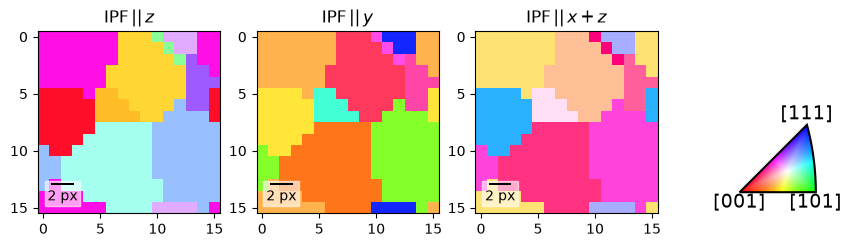

In [7]:
fig = plt.figure(figsize=(8, 8))
for i, IPF_direction in enumerate(IPF_directions):
    IPF_color_key = IPFColorKeyTSL(phase.point_group,Vector3d(IPF_direction))
    IPF_color = IPF_color_key.orientation2color(O_orix.flatten())
    ax = fig.add_subplot(1,len(IPF_directions),i+1, projection="plot_map")
    ax.plot_map(m,IPF_color)
    ax.set_title(rf'$\mathregular{{IPF}}\,||\,{as_xyz(IPF_direction)}$')

ax_ckey = fig.add_axes(
    [1, 0.4, 0.1, 0.1], projection="ipf", symmetry=phase.point_group.laue, zorder=2
)
ax_ckey.plot_ipf_color_key(show_title=False)
fig.show()

## Plot with DAMASK functionality
- helps to ensure that the quaternion was correctly interpreted
- the small deviations between coloring in orix and DAMASK result from maginally different color mapping

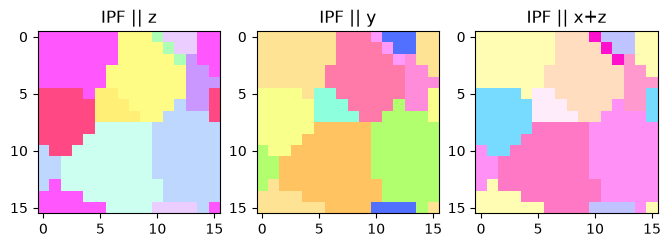

In [8]:
fig = plt.figure(figsize=(8, 8))
for i, IPF_direction in enumerate(IPF_directions):
    result.add_IPF_color(IPF_direction)
    IPF_color = result.place(f'IPFcolor_({IPF_direction[0]} {IPF_direction[1]} {IPF_direction[2]})') # read from file
    IPF_color = damask.grid_filters.unravel(IPF_color,result.cells) # reshape to regular grid
    IPF_color = IPF_color[selection[0],selection[1],selection[2]] # select slice
    ax = fig.add_subplot(1,len(IPF_directions),i+1)
    ax.imshow(np.swapaxes(IPF_color,1,0))
    ax.set_title(f'IPF || {as_xyz(IPF_direction)}')
fig.show()